<h2 style="color:#5B7DB1;">1. Imports &amp; Setup</h2>

### Marketplace Seller Risk & Loss Prevention: Initial Report & Exploratory Data Analysis

**Research Question:** How can marketplace payment platforms augment traditional rule-based loss prevention systems with a unified machine learning framework to identify high-risk sellers, estimate potential financial losses, and forecast portfolio-level risk before seller payouts are released?

**Dataset:** [Olist Brazilian E-Commerce Dataset](https://www.kaggle.com/datasets/olistbr/brazilian-ecommerce) (Kaggle) — ~100K orders across customers, sellers, products, payments, and reviews (2016-2018).

**Module 16 scope:** This notebook addresses the initial stage of the broader capstone research question. It includes data-quality assessment, data cleaning, exploratory data analysis, outlier analysis, seller-level feature engineering, and the development of a baseline classification model for identifying sellers with elevated operational-risk patterns. Seller segmentation using PCA and K-Means, expanded model comparison, and portfolio-level risk forecasting are planned for Module 24.

**Target variable and Key Limitation:** The Olist dataset does not contain confirmed fraud, chargeback, seller payout, or financial-loss labels. Therefore, this analysis constructs a proxy high-risk seller target using three observable operational signals: order-cancellation rate, late-delivery rate, and negative-review rate. The resulting target represents operational or service-related risk and should not be interpreted as confirmed financial fraud. Its construction, assumptions, and limitations are discussed in Section 9.

In [67]:
import pandas as pd                                         #used to load, clean, merge, group, and analyze tables
import numpy as np                                           #used for numerical calculations and missing values
import matplotlib.pyplot as plt                              #creates charts
import seaborn as sns                                        #creates clearer statistical visualizations

from sklearn.model_selection import train_test_split         #separates the data into training and testing sets.
from sklearn.preprocessing import StandardScaler             #standardizes numerical features
from sklearn.linear_model import LogisticRegression          #builds the baseline classification model
from sklearn.ensemble import RandomForestClassifier          #builds the comparison model.
from sklearn.metrics import (classification_report, confusion_matrix, roc_auc_score,
                              roc_curve, average_precision_score, f1_score,
                              precision_score, recall_score) #measure model performance

sns.set_theme(style='whitegrid')
pd.set_option('display.max_columns', 60)
pd.set_option('display.width', 160)
RNG = 42                                      #makes random results reproducible to retain train/test model behavior

RAW = 'data/'
print('Setup complete.')

Setup complete.


<h2 style="color:#5B7DB1;">2. Data Loading</h2>

In [68]:
customers = pd.read_csv(RAW + 'olist_customers_dataset.csv')
geo = pd.read_csv(RAW + 'olist_geolocation_dataset.csv')
order_items = pd.read_csv(RAW + 'olist_order_items_dataset.csv')
payments = pd.read_csv(RAW + 'olist_order_payments_dataset.csv')
reviews = pd.read_csv(RAW + 'olist_order_reviews_dataset.csv')
orders = pd.read_csv(RAW + 'olist_orders_dataset.csv')
products = pd.read_csv(RAW + 'olist_products_dataset.csv')
sellers = pd.read_csv(RAW + 'olist_sellers_dataset.csv')
cat_translation = pd.read_csv(RAW + 'product_category_name_translation.csv')

for name, df in [('customers', customers), ('geolocation', geo), ('order_items', order_items),
                  ('payments', payments), ('reviews', reviews), ('orders', orders),
                  ('products', products), ('sellers', sellers), ('cat_translation', cat_translation)]:
    print(f'{name:15s} {df.shape}')

customers       (99441, 5)
geolocation     (1000163, 5)
order_items     (112650, 7)
payments        (103886, 5)
reviews         (99224, 7)
orders          (99441, 8)
products        (32951, 9)
sellers         (3095, 4)
cat_translation (71, 2)


<h2 style="color:#5B7DB1;">3. Data Quality Assessment</h2>

<p style="color:black;">
<strong></strong> Before cleaning, we check each table for missing values and duplicate rows.
</p>

In [69]:
print('=== MISSING VALUES ===')
for name, df in [('orders', orders), ('order_items', order_items), ('payments', payments),
                  ('reviews', reviews), ('products', products), ('sellers', sellers), ('customers', customers)]:
    miss = df.isna().sum()
    miss = miss[miss > 0]
    if len(miss):
        print(f'\n-- {name} --')
        print(miss)

print('\n=== DUPLICATE ROWS ===')
for name, df in [('orders', orders), ('order_items', order_items), ('payments', payments),
                  ('reviews', reviews), ('products', products), ('sellers', sellers), ('customers', customers)]:
    print(f'{name:15s} duplicates: {df.duplicated().sum()}')

=== MISSING VALUES ===

-- orders --
order_approved_at                 160
order_delivered_carrier_date     1783
order_delivered_customer_date    2965
dtype: int64

-- reviews --
review_comment_title      87656
review_comment_message    58247
dtype: int64

-- products --
product_category_name         610
product_name_lenght           610
product_description_lenght    610
product_photos_qty            610
product_weight_g                2
product_length_cm               2
product_height_cm               2
product_width_cm                2
dtype: int64

=== DUPLICATE ROWS ===
orders          duplicates: 0
order_items     duplicates: 0
payments        duplicates: 0
reviews         duplicates: 0
products        duplicates: 0
sellers         duplicates: 0
customers       duplicates: 0


### Data Quality Assessment: Results

### Duplicate Rows

No exact duplicate rows were found in the core tables.

No duplicate-row removal was required. This confirms that the tables do not contain fully identical records; key-level uniqueness is evaluated separately where relevant.

### Missing Values

Missing values were identified in three tables. Their meaning and appropriate treatment depend on the field.

| Table | Missing Field | Rows Missing | Interpretation |
|---|---|---:|---|
| Orders | Delivered-to-customer date | 2,965 (~3%) | These orders do not have a recorded final delivery. This may occur for canceled, unavailable, undelivered, or incomplete orders. The missing value may contain useful operational information. |
| Orders | Delivered-to-carrier date | 1,783 (~2%) | These orders do not have a recorded handoff to the carrier, indicating that they may not have progressed to that stage of fulfillment. |
| Orders | Approved-at date | 160 (<1%) | These orders do not have a recorded payment-approval timestamp. |
| Reviews | Written comment | 58,247 (~59%) | Written comments are optional. Many customers provide a star rating without entering a written review. |
| Reviews | Comment title | 87,656 (~88%) | Review titles are also optional and are left blank by most customers. |
| Products | Category, name length, description length, and photo count | 610 (~2%) | A small portion of product listings have incomplete descriptive information. |
| Products | Weight or dimensions | 2 rows | Only 2 of approximately 33,000 product records are affected, making the impact negligible. |

### Key Takeaways

The missing data falls into two main categories:

1. **Potentially meaningful missing values:** Missing fulfillment dates may indicate that an order was canceled, unavailable, or never completed. These values will not be imputed because the absence of a delivery event may itself be relevant to seller-risk analysis.

2. **Optional or incomplete descriptive fields:** Missing review comments and titles represent normal customer behavior rather than a data-quality failure. Missing product categories will be labeled as `unknown`, while the very small number of missing product measurements can be handled using median imputation.

### Conclusion

No rows need to be removed solely because of exact duplicates or missing values. The complete dataset can therefore be retained for the cleaning and feature-engineering stages, with missing values handled according to their business meaning.

<h2 style="color:#5B7DB1;">4. Data Cleaning</h2>

**Decisions:**
- Parse all date columns to `datetime`.
- Drop exact duplicate rows (none found, but this is checked defensively).
- Missing `product_category_name` (610 rows, <2%) → filled as `'unknown'` rather than dropped, since the row still carries valid price/seller/order information.
- Missing numeric product dimensions (2 rows) → median imputation (negligible impact).
- Missing `review_comment_message`/`title` → this is **expected**, not an error (most reviewers leave a star rating without a written comment). We keep it as a `has_comment` flag rather than imputing text.
- Missing delivery dates (`order_delivered_customer_date`, ~3%) → **not imputed**; these correspond to orders that were canceled/undelivered, which is itself a meaningful risk signal we use later.

In [70]:
date_cols = ['order_purchase_timestamp', 'order_approved_at', 'order_delivered_carrier_date',
             'order_delivered_customer_date', 'order_estimated_delivery_date']
for c in date_cols:
    orders[c] = pd.to_datetime(orders[c], errors='coerce')
order_items['shipping_limit_date'] = pd.to_datetime(order_items['shipping_limit_date'], errors='coerce')
reviews['review_creation_date'] = pd.to_datetime(reviews['review_creation_date'], errors='coerce')
reviews['review_answer_timestamp'] = pd.to_datetime(reviews['review_answer_timestamp'], errors='coerce')

for df in [orders, order_items, payments, reviews, products, sellers, customers]:
    df.drop_duplicates(inplace=True)

products['product_category_name'] = products['product_category_name'].fillna('unknown')
products = products.merge(cat_translation, on='product_category_name', how='left')
products['product_category_name_english'] = products['product_category_name_english'].fillna('unknown')
for c in ['product_weight_g', 'product_length_cm', 'product_height_cm', 'product_width_cm',
          'product_name_lenght', 'product_description_lenght', 'product_photos_qty']:
    products[c] = products[c].fillna(products[c].median())

reviews['has_comment'] = reviews['review_comment_message'].notna().astype(int)

print('Order status distribution:')
print(orders['order_status'].value_counts())

Order status distribution:
delivered      96478
shipped         1107
canceled         625
unavailable      609
invoiced         314
processing       301
created            5
approved           2
Name: order_status, dtype: int64


### Order Status Distribution: Interpretation

The dataset contains **99,441 orders**, of which **96,478 (approximately 97%)** were successfully delivered. This indicates that most orders completed the normal fulfillment process.

A much smaller number remained in other stages:

- **1,107 orders (1.1%)** were marked as shipped but did not have a final delivered status.
- **625 orders (0.6%)** were canceled.
- **609 orders (0.6%)** were unavailable.
- **314 orders (0.3%)** were invoiced.
- **301 orders (0.3%)** were still processing.
- Only **5 orders** were marked as created and **2 orders** as approved.

Combined, canceled and unavailable orders represent approximately **1.2% of all orders**. Although this is a relatively small proportion, these incomplete orders are important for the seller-risk analysis because unusually high cancellation or non-completion rates may indicate operational problems.

The distribution is highly imbalanced toward delivered orders. Therefore, percentages and seller-level rates will be more informative than raw order counts when comparing seller performance.

<h2 style="color:#5B7DB1;">5. Building the Order-Level Master Table</h2>

We merge order items, payments, reviews, products, customers, and sellers onto the orders table (one row per order, using the primary line-item seller/product for order-level analysis, with item counts/totals aggregated).

In [71]:
item_agg = order_items.groupby('order_id').agg(
    n_items=('order_item_id', 'count'), n_sellers=('seller_id', 'nunique'),
    n_products=('product_id', 'nunique'), items_price=('price', 'sum'),
    items_freight=('freight_value', 'sum')).reset_index()

primary_item = order_items.sort_values('order_item_id').drop_duplicates('order_id', keep='first')
primary_item = primary_item[['order_id', 'seller_id', 'product_id']]

pay_agg = payments.groupby('order_id').agg(
    payment_value=('payment_value', 'sum'), n_payment_installments=('payment_installments', 'max'),
    payment_type=('payment_type', lambda x: x.mode().iat[0] if not x.mode().empty else 'unknown')).reset_index()

rev_agg = reviews.groupby('order_id').agg(
    review_score=('review_score', 'mean'), has_comment=('has_comment', 'max')).reset_index()

master = orders.merge(item_agg, on='order_id', how='left') \
               .merge(primary_item, on='order_id', how='left') \
               .merge(pay_agg, on='order_id', how='left') \
               .merge(rev_agg, on='order_id', how='left') \
               .merge(products[['product_id', 'product_category_name_english']], on='product_id', how='left') \
               .merge(customers[['customer_id', 'customer_state', 'customer_city']], on='customer_id', how='left') \
               .merge(sellers[['seller_id', 'seller_state', 'seller_city']], on='seller_id', how='left')

master['delivery_days'] = (master['order_delivered_customer_date'] - master['order_purchase_timestamp']).dt.days
master['delay_days'] = (master['order_delivered_customer_date'] - master['order_estimated_delivery_date']).dt.days
master['is_late'] = (master['delay_days'] > 0).astype('Int64')
master['is_canceled'] = (master['order_status'].isin(['canceled', 'unavailable'])).astype(int)

print('Master table shape:', master.shape)
master.head(3)

Master table shape: (99441, 29)


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,n_items,n_sellers,n_products,items_price,items_freight,seller_id,product_id,payment_value,n_payment_installments,payment_type,review_score,has_comment,product_category_name_english,customer_state,customer_city,seller_state,seller_city,delivery_days,delay_days,is_late,is_canceled
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,1.0,1.0,1.0,29.99,8.72,3504c0cb71d7fa48d967e0e4c94d59d9,87285b34884572647811a353c7ac498a,38.71,1.0,voucher,4.0,1.0,housewares,SP,sao paulo,SP,maua,8.0,-8.0,0,0
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,1.0,1.0,1.0,118.70,22.76,289cdb325fb7e7f891c38608bf9e0962,595fac2a385ac33a80bd5114aec74eb8,141.46,1.0,boleto,4.0,1.0,perfumery,BA,barreiras,SP,belo horizonte,13.0,-6.0,0,0
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,1.0,1.0,1.0,159.90,19.22,4869f7a5dfa277a7dca6462dcf3b52b2,aa4383b373c6aca5d8797843e5594415,179.12,3.0,credit_card,5.0,0.0,auto,GO,vianopolis,SP,guariba,9.0,-18.0,0,0


<h2 style="color:#5B7DB1;">6. Order-Level Exploratory Data Analysis</h2>

### Order Status Distribution

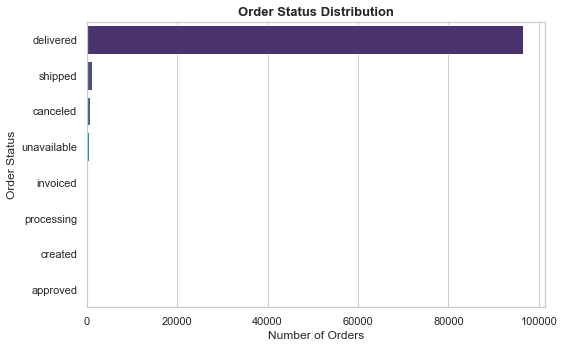

In [72]:
fig, ax = plt.subplots(figsize=(8, 5))
order_counts = master['order_status'].value_counts()
sns.barplot(x=order_counts.values, y=order_counts.index, ax=ax, palette='viridis')
ax.set_title('Order Status Distribution', fontsize=13, fontweight='bold')
ax.set_xlabel('Number of Orders'); ax.set_ylabel('Order Status')
plt.tight_layout(); 
plt.show()

### Observations: 

**What this shows:** the breakdown of all 99,441 orders by their current status.

**Key observation:** the dataset is overwhelmingly dominated by `delivered` orders — roughly 96,500 of ~99,400 total orders, or **about 97%**. Every other status (shipped, canceled, unavailable, invoiced, processing, created, approved) is a small sliver by comparison, each under 1,200 orders.

**What this tells us:**

1. **The Olist marketplace has a healthy fulfillment rate overall.** Most orders complete the full journey from purchase to delivery without issue — this is the "normal" baseline our risk model needs to distinguish sellers from.

2. **The "risk" signal we care about is a minority pattern.** `canceled` (~625) and `unavailable` (~609) orders — the two statuses we treat as failed/risky outcomes — together make up roughly **1.2%** of all orders. This confirms what we expected going in: seller risk events are rare, which is exactly why we built a percentile-based proxy target instead of predicting a naturally occurring class split, and why class imbalance techniques (class weighting, and SMOTE later) are necessary rather than optional.

3. **The remaining statuses are pipeline/in-progress states**, not failures — `shipped`, `invoiced`, `processing`, `created`, and `approved` represent orders still moving through the system at the time the dataset was captured, not orders that went wrong. We don't treat these as risk signals.

**Why this matters for the bigger picture:** this order-level view validates the seller-level risk target we build later. If cancellations were, say, 30% of all orders, our whole "top 20% = high risk" framing would need rethinking. At ~1%, it confirms risk events are rare outliers, which lines up with real-world marketplace fraud/loss patterns — the vast majority of sellers behave normally, and the model's job is to find the small minority that don't.

### Monthly Order Volume Over Time

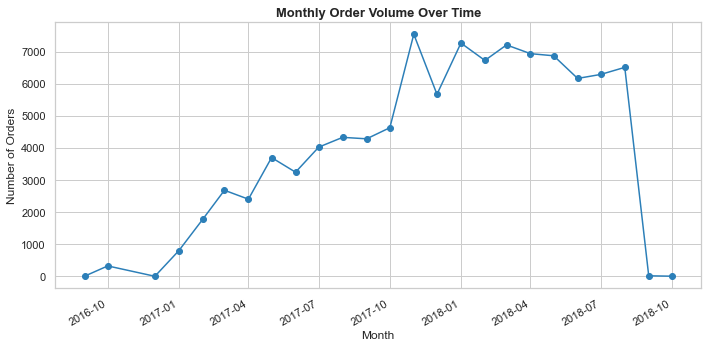

In [73]:
ts = master.copy()
ts['month'] = ts['order_purchase_timestamp'].dt.to_period('M').dt.to_timestamp()
monthly_orders = ts.groupby('month')['order_id'].nunique()
fig, ax = plt.subplots(figsize=(10, 5))
monthly_orders.plot(ax=ax, marker='o', color='#2c7fb8')
ax.set_title('Monthly Order Volume Over Time', fontsize=13, fontweight='bold')
ax.set_xlabel('Month'); ax.set_ylabel('Number of Orders')
plt.tight_layout(); plt.show()

**Observations:** 
- Order volume grows steadily from a near-zero launch in late 2016 to roughly 7,000+ orders/month by late 2017, then plateaus in that 6,000-7,000 range through mid-2018 : a healthy growth-then-maturity pattern rather than runaway or declining growth. 
- There's a sharp spike around November 2017 (consistent with Black Friday seasonality) followed by an equally sharp dip the next month, which is a normal post-holiday pullback, not a data error. 
- The steep drop to near-zero after September 2018 is **not a business collapse** : it's simply where the dataset extraction ends, so there's incomplete data for the final month(s). 

We exclude that tail from any trend-based conclusions to avoid mistaking a data cutoff for a business event.

### Payment Type Distribution & Review Score Distribution

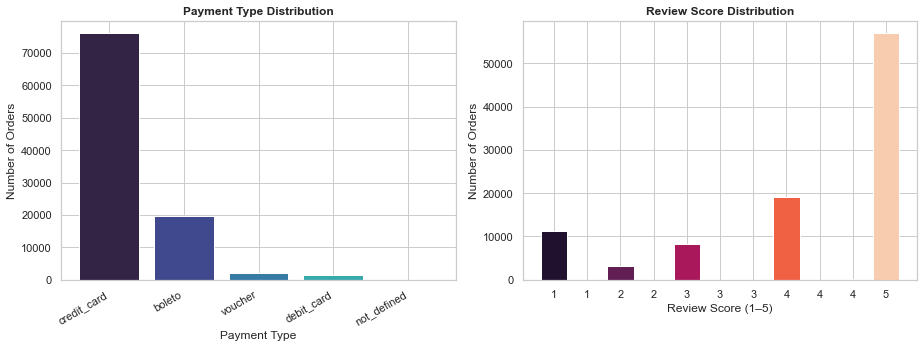

In [74]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# ----------------------------
# Payment Type Distribution
# ----------------------------
pay_counts = master['payment_type'].dropna().value_counts()

payment_labels = pay_counts.index.astype(str)
payment_positions = range(len(payment_labels))
payment_colors = sns.color_palette('mako', len(payment_labels))

axes[0].bar(
    payment_positions,
    pay_counts.values,
    color=payment_colors
)

axes[0].set_xticks(list(payment_positions))
axes[0].set_xticklabels(payment_labels, rotation=30, ha='right')
axes[0].set_title('Payment Type Distribution', fontweight='bold')
axes[0].set_xlabel('Payment Type')
axes[0].set_ylabel('Number of Orders')


# ----------------------------
# Review Score Distribution
# ----------------------------
rev_counts = master['review_score'].dropna().value_counts().sort_index()

review_labels = [str(int(score)) for score in rev_counts.index]
review_positions = range(len(review_labels))
review_colors = sns.color_palette('rocket', len(review_labels))

axes[1].bar(
    review_positions,
    rev_counts.values,
    color=review_colors
)

axes[1].set_xticks(list(review_positions))
axes[1].set_xticklabels(review_labels)
axes[1].set_title('Review Score Distribution', fontweight='bold')
axes[1].set_xlabel('Review Score (1–5)')
axes[1].set_ylabel('Number of Orders')

plt.tight_layout()
plt.show()

**Observations:**
- **Payment type:** credit card is the dominant payment method by a wide margin (roughly three-quarters of all orders), followed distantly by boleto (a Brazilian bank-slip payment method, approx. 20%), with debit card and voucher each under 3%. This matters for the risk model - heavy boleto usage ties into our `avg_installments`/payment-behavior features, since boleto and installment patterns can be weak signals of buyer or seller financial stress.
- **Review scores:** the distribution is strongly right-skewed toward positive : 5-star reviews are by far the most common outcome, with 4-star second. However, the x-axis shows several decimal values (e.g., 3.33, 4.5) alongside whole numbers,  this is because a small number of orders contain multiple line items with different review scores, and we averaged them at the order level. It's a minor artifact worth noting, not a data error; the seller-level features later use a cleaner mean-per-seller aggregation.M

### Delivery Time Distribution & Delivery Delay vs Estimate (days)

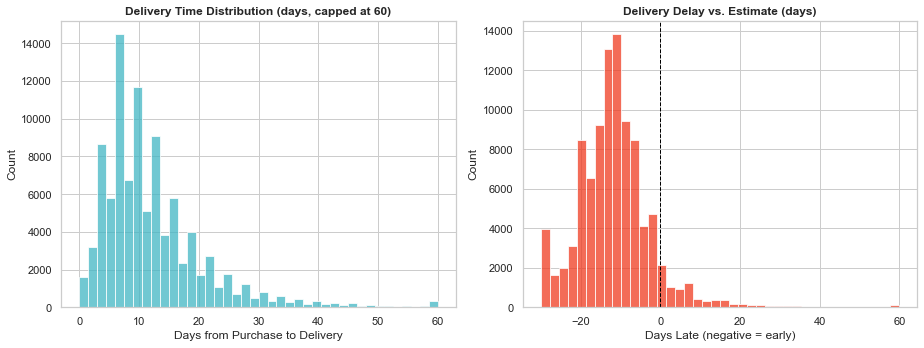

In [75]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
sns.histplot(master['delivery_days'].dropna().clip(upper=60), bins=40, ax=axes[0], color='#41b6c4')
axes[0].set_title('Delivery Time Distribution (days, capped at 60)', fontweight='bold')
axes[0].set_xlabel('Days from Purchase to Delivery')

sns.histplot(master['delay_days'].dropna().clip(-30, 60), bins=40, ax=axes[1], color='#f03b20')
axes[1].axvline(0, color='black', linestyle='--', linewidth=1)
axes[1].set_title('Delivery Delay vs. Estimate (days)', fontweight='bold')
axes[1].set_xlabel('Days Late (negative = early)')
plt.tight_layout(); plt.show()

**Observations:** 
- Most orders are delivered within roughly 5-15 days of purchase, with the distribution tailing off sharply after that very few orders take longer than 40-50 days. More importantly, the delay chart (right) shows the bulk of orders land to the **left** of the dashed zero line, meaning Olist's estimated delivery dates are conservative: most orders arrive **earlier** than promised, not later. 
- Only a modest right-side tail extends past zero, representing genuinely late deliveries. 

This is useful context for the risk model: because early/on-time delivery is the norm, a seller with a meaningfully long right-tail delay pattern stands out clearly as an outlier rather than blending into normal variation.

### Customer States by Order Volume

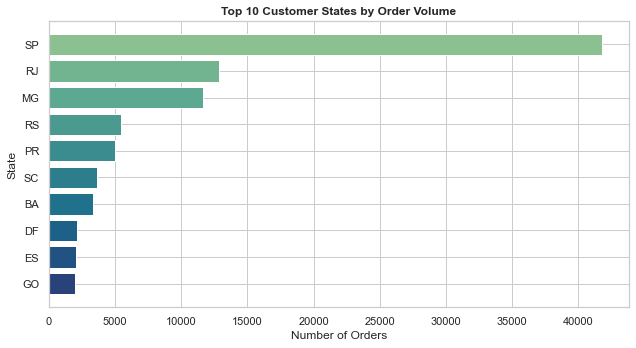

In [76]:
fig, ax = plt.subplots(figsize=(9, 5))

# Top 10 customer states
state_counts = master['customer_state'].dropna().value_counts().head(10)

state_labels = state_counts.index.astype(str)
state_positions = range(len(state_labels))
state_colors = sns.color_palette('crest', len(state_labels))

# Horizontal bar chart
ax.barh(
    state_positions,
    state_counts.values,
    color=state_colors
)

ax.set_yticks(list(state_positions))
ax.set_yticklabels(state_labels)

# Place the state with the highest number of orders at the top
ax.invert_yaxis()

ax.set_title(
    'Top 10 Customer States by Order Volume',
    fontweight='bold'
)
ax.set_xlabel('Number of Orders')
ax.set_ylabel('State')

plt.tight_layout()
plt.show()

**Observations:** 
- São Paulo (SP) dominates order volume by a wide margin over 40,000 of the top-10-state total, roughly 3x the next closest state (Rio de Janeiro, RJ). 
- Minas Gerais (MG) rounds out the top 3, and the remaining states drop off steadily. 

This heavy geographic concentration (SP alone represents a large share of total national order volume) means our seller-state feature will be dominated by a single category, so state-level effects should be interpreted cautiously, a "high-risk state" finding could partly reflect SP's sheer volume advantage rather than a true regional risk difference. We revisit this with a normalized view (risk *rate* by state, not raw count) in Section 10.

<h2 style="color:#5B7DB1;">7. Feature Engineering — Seller-Level Dataset</h2>

The research question requires a **seller-level** dataset (one record per seller). We engineer behavioral features across tenure, volume, payment behavior, delivery performance, reviews, cancellations, monthly trend/volatility, and activity patterns, as outlined in the project problem statement.

In [77]:
m = master.dropna(subset=['seller_id']).copy()
DATASET_END = m['order_purchase_timestamp'].max()

item_seller = order_items[['order_id', 'seller_id', 'price', 'freight_value']]
seller_reviews = item_seller.merge(reviews[['order_id', 'review_score']], on='order_id', how='left')

# 1. Tenure & activity window
tenure = m.groupby('seller_id')['order_purchase_timestamp'].agg(['min', 'max', 'count'])
tenure['seller_tenure_days'] = (DATASET_END - tenure['min']).dt.days
tenure['active_span_days'] = (tenure['max'] - tenure['min']).dt.days.clip(lower=1)

# 2. Order volume / revenue
vol = m.groupby('seller_id').agg(n_orders=('order_id', 'nunique'), total_revenue=('items_price', 'sum'),
    avg_order_value=('items_price', 'mean'), std_order_value=('items_price', 'std'),
    avg_freight=('items_freight', 'mean'))

# 3. Payment behavior
pay = m.groupby('seller_id').agg(avg_installments=('n_payment_installments', 'mean'))
pay_type_share = pd.crosstab(m['seller_id'], m['payment_type'], normalize='index').add_prefix('pct_pay_')

# 4. Delivery performance
delivery = m.groupby('seller_id').agg(avg_delivery_days=('delivery_days', 'mean'),
    avg_delay_days=('delay_days', 'mean'), pct_late=('is_late', 'mean'))

# 5. Review scores
rev = seller_reviews.groupby('seller_id').agg(avg_review_score=('review_score', 'mean'),
    pct_low_reviews=('review_score', lambda x: (x <= 2).mean()), n_reviews=('review_score', 'count'))

# 6. Cancellation / refund proxy rate
cancel = m.groupby('seller_id').agg(pct_canceled=('is_canceled', 'mean'), n_canceled=('is_canceled', 'sum'))

# 7. Monthly sales trend / volatility
m['order_month'] = m['order_purchase_timestamp'].dt.to_period('M')
monthly = m.groupby(['seller_id', 'order_month'])['items_price'].sum().reset_index()
monthly_stats = monthly.groupby('seller_id')['items_price'].agg(
    monthly_revenue_std='std', monthly_revenue_mean='mean', n_active_months='count')
monthly_stats['revenue_volatility'] = (monthly_stats['monthly_revenue_std'] /
                                        monthly_stats['monthly_revenue_mean'].replace(0, np.nan))

# 8. Activity pattern: category diversity
activity = m.groupby('seller_id').agg(n_categories=('product_category_name_english', 'nunique'))

feat = sellers.set_index('seller_id')[['seller_state', 'seller_city']].copy()
feat = feat.join([tenure[['seller_tenure_days', 'active_span_days']], vol, pay, pay_type_share,
                   delivery, rev, cancel, monthly_stats[['n_active_months', 'revenue_volatility']],
                   activity], how='left')
feat['orders_per_active_month'] = feat['n_orders'] / feat['n_active_months'].replace(0, np.nan)
feat = feat.dropna(subset=['n_orders'])

print('Seller feature table shape:', feat.shape)
print('\nMissing values:')
print(feat.isna().sum()[feat.isna().sum() > 0])

Seller feature table shape: (3088, 26)

Missing values:
std_order_value       578
avg_delivery_days     128
avg_delay_days        128
avg_review_score        5
revenue_volatility    758
dtype: int64


In [78]:
num_cols = feat.select_dtypes(include=[np.number]).columns
for c in num_cols:
    feat[c] = feat[c].fillna(feat[c].median())
print('Missing values remaining:', feat[num_cols].isna().sum().sum())
feat.head(3)

Missing values remaining: 0


,seller_state,seller_city,seller_tenure_days,active_span_days,n_orders,total_revenue,avg_order_value,std_order_value,avg_freight,avg_installments,pct_pay_boleto,pct_pay_credit_card,pct_pay_debit_card,pct_pay_voucher,avg_delivery_days,avg_delay_days,pct_late,avg_review_score,pct_low_reviews,n_reviews,pct_canceled,n_canceled,n_active_months,revenue_volatility,n_categories,orders_per_active_month
seller_id,,,,,,,,,,,,,,,,,,,,,,,,,,
3442f8959a84dea7ee197c632cb2df15,SP,campinas,485.0,108.0,2.0,207.90,103.95000,3.181981,12.74000,2.000,0.000,1.000,0.0,0.0,18.00000,0.500000,0.5,3.000000,0.333333,3,0.000,0.0,2.0,0.030611,1.0,1.000000
d1b65fc7debc3361ea86b5f14c68d2e2,SP,mogi guacu,524.0,435.0,40.0,11703.07,292.57675,256.773227,35.96825,4.525,0.175,0.825,0.0,0.0,8.74359,-15.974359,0.025,4.560976,0.048780,41,0.025,1.0,12.0,1.085849,3.0,3.333333
ce3ad9de960102d0677a81f5d0bb7b2d,RJ,rio de janeiro,34.0,1.0,1.0,158.00,158.00000,53.397034,16.21000,3.000,0.000,1.000,0.0,0.0,4.00000,-13.000000,0.0,5.000000,0.000000,1,0.000,0.0,1.0,0.659466,1.0,1.000000


**Observations:** 

- The raw transactional data (99,441 orders) collapses down to **3,088 seller records** with 26 engineered behavioral features. A handful of features have missing values for a subset of sellers — `std_order_value` (sellers with only 1 order have no standard deviation to compute), `avg_delivery_days`/`avg_delay_days` (sellers whose orders never reached a delivered state), and `revenue_volatility` (sellers active in only a single month). 
- These aren't data quality problems — they're mathematically undefined for low-activity sellers, which is itself informative (a brand-new or very low-volume seller is a different risk profile than an established one). 
- We median-impute these next so no seller is dropped, while keeping this low-activity signal captured elsewhere (`n_orders`, `n_active_months`).

<h2 style="color:#5B7DB1;">8. Outlier Analysis</h2>

Revenue and order-value features are heavily right-skewed (a small number of high-volume sellers). We winsorize (cap) these at the 1st/99th percentile rather than deleting rows, preserving sample size while limiting the influence of extreme values on the model.

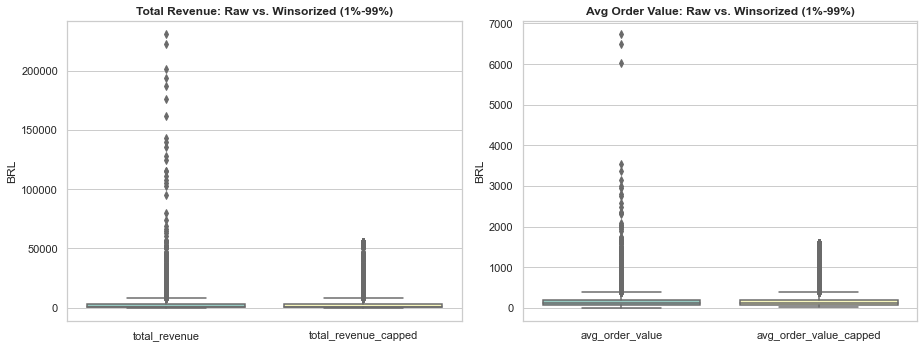

In [79]:
cap_cols = ['total_revenue', 'avg_order_value', 'std_order_value', 'avg_freight', 'avg_delivery_days']
for c in cap_cols:
    lo, hi = feat[c].quantile([0.01, 0.99])
    feat[c + '_capped'] = feat[c].clip(lo, hi)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
sns.boxplot(data=feat[['total_revenue', 'total_revenue_capped']], ax=axes[0], palette='Set3')
axes[0].set_title('Total Revenue: Raw vs. Winsorized (1%-99%)', fontweight='bold'); axes[0].set_ylabel('BRL')
sns.boxplot(data=feat[['avg_order_value', 'avg_order_value_capped']], ax=axes[1], palette='Set3')
axes[1].set_title('Avg Order Value: Raw vs. Winsorized (1%-99%)', fontweight='bold'); axes[1].set_ylabel('BRL')
plt.tight_layout(); plt.show()

**Observations:** 

- Both revenue and order-value features show a small number of extreme high-value outliers before capping (a handful of sellers with total revenue or average order values many times the typical seller). 
- After winsorizing at the 1st/99th percentile, the extreme tail is pulled in while the bulk of the distribution (and every seller's relative ranking) is preserved. 

This matters for the baseline model without capping, a linear model like Logistic Regression could let a small number of extreme-revenue sellers disproportionately influence the fitted coefficients, even though those sellers may be entirely low-risk.

<h2 style="color:#5B7DB1;">9. Target Variable: Composite Risk Proxy</h2>

Olist has no explicit fraud/chargeback label. We define a **proxy risk target** from three signals a marketplace risk team already tracks operationally: cancellation rate, late-delivery rate, and negative-review rate. Each is percentile-ranked and combined into a weighted `risk_score`; the top quintile (80th percentile) is flagged `high_risk_seller = 1`.

**Limitation:** this proxy captures *operational/service risk*, not necessarily *financial fraud*. A production system would ideally replace it with realized chargeback/loss data; we flag this explicitly as a modeling assumption for the research question.

Target balance:
0    0.798899
1    0.201101
Name: high_risk_seller, dtype: float64


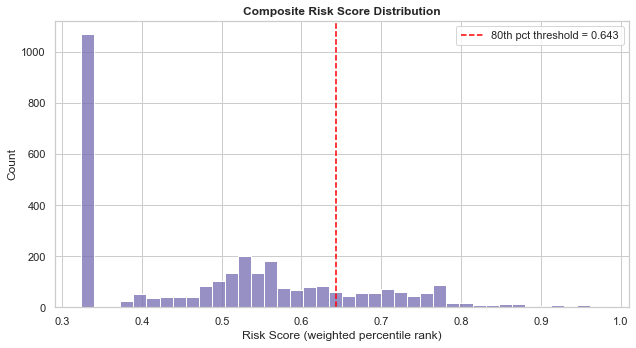

In [80]:
feat['risk_score'] = (feat['pct_canceled'].rank(pct=True) * 0.4 +
                       feat['pct_late'].rank(pct=True) * 0.3 +
                       feat['pct_low_reviews'].rank(pct=True) * 0.3)
threshold = feat['risk_score'].quantile(0.80)
feat['high_risk_seller'] = (feat['risk_score'] >= threshold).astype(int)

print('Target balance:')
print(feat['high_risk_seller'].value_counts(normalize=True))

fig, ax = plt.subplots(figsize=(9, 5))
sns.histplot(feat['risk_score'], bins=40, ax=ax, color='#756bb1')
ax.axvline(threshold, color='red', linestyle='--', label=f'80th pct threshold = {threshold:.3f}')
ax.set_title('Composite Risk Score Distribution', fontweight='bold')
ax.set_xlabel('Risk Score (weighted percentile rank)'); ax.legend()
plt.tight_layout(); plt.show()

**Observations:** 

- The risk score distribution has a distinct spike near approx. 0.33. This is a large cluster of sellers who all score identically low on the three underlying components (essentially zero cancellations, zero late deliveries, no negative reviews), so they land on the same percentile-rank value. 
- Above that spike, the distribution spreads out fairly evenly until the 80th-percentile cutoff (approx. 0.643), which we use as the high-risk threshold. 
- Roughly 20% of sellers fall at or above that line by construction. This is the deliberate design of a percentile based target, not a naturally occurring split, which is why we describe `high_risk_seller` as a proxy rather than ground truth throughout this notebook.

<h2 style="color:#5B7DB1;">10. Seller-Level Exploratory Data Analysis</h2>

### Correlation Heatmap: Seller-Level Risk Features

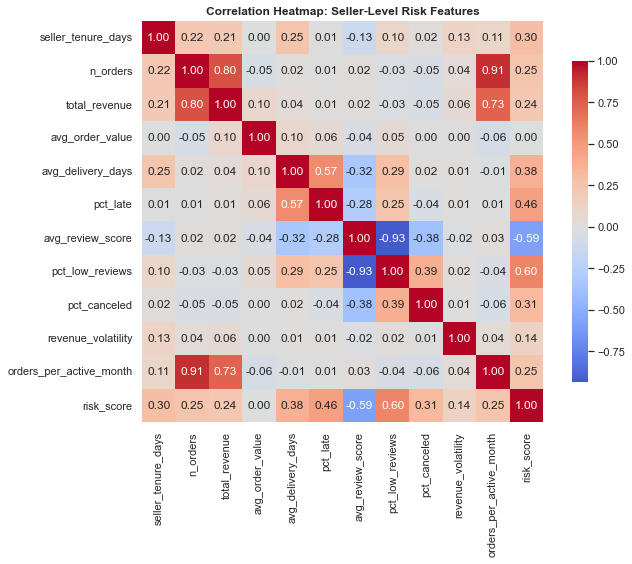

In [81]:
key_cols = ['seller_tenure_days', 'n_orders', 'total_revenue', 'avg_order_value',
            'avg_delivery_days', 'pct_late', 'avg_review_score', 'pct_low_reviews',
            'pct_canceled', 'revenue_volatility', 'orders_per_active_month', 'risk_score']
fig, ax = plt.subplots(figsize=(10, 8))
corr = feat[key_cols].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0, ax=ax, square=True,
            cbar_kws={'shrink': 0.8})
ax.set_title('Correlation Heatmap: Seller-Level Risk Features', fontweight='bold')
plt.tight_layout(); plt.show()

**Observations:** 

- Several correlations validate our feature design choices. `avg_review_score` and `pct_low_reviews` are strongly negatively correlated (r ≈ -0.93), as expected — they're two views of the same underlying signal, which is exactly why we exclude both from the model features later (Section 11) to avoid redundancy/leakage. `avg_delivery_days` and `pct_late` correlate moderately (r ≈ 0.57), confirming slower average delivery genuinely tracks with more late deliveries rather than being noise. `n_orders` and `orders_per_active_month` correlate very strongly (r ≈ 0.91), so we should be cautious about including both as independent predictors — they carry largely the same information. 

- Most importantly, `risk_score` correlates most strongly with `pct_low_reviews` (r ≈ 0.60) and `avg_review_score` (r ≈ -0.59), which makes sense given how the score was constructed, and reinforces why those exact components must be excluded from the predictive model.

### Cancellation Rate, Late Delivery Rate, Average Review Score, Average Order Value

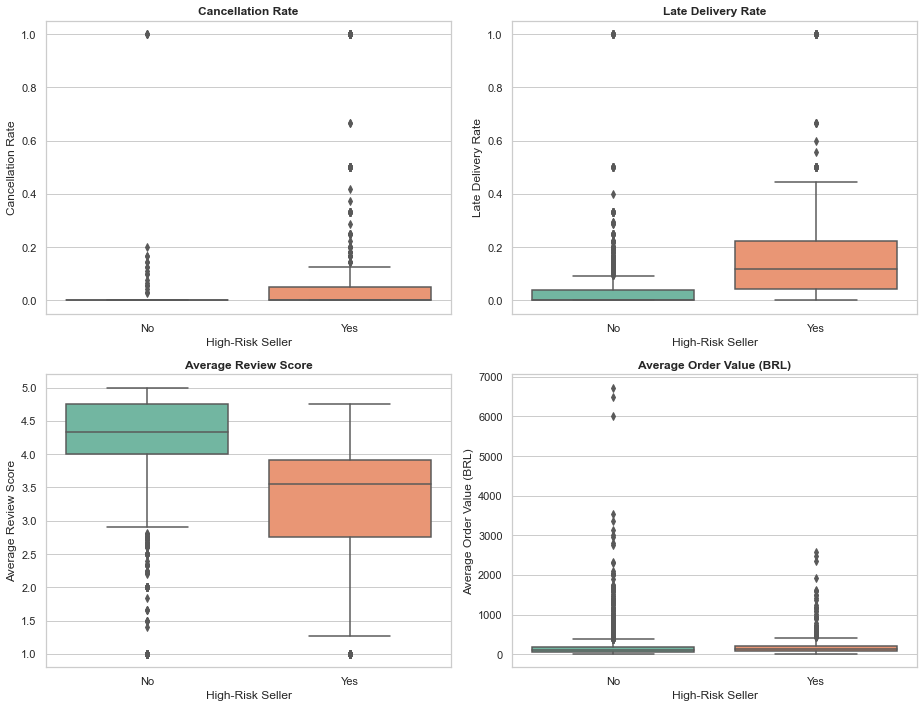

In [82]:
# Check and clean column names
feat.columns = feat.columns.str.strip()



# Create the boxplots
fig, axes = plt.subplots(2, 2, figsize=(13, 10))

plot_specs = [
    ('pct_canceled', 'Cancellation Rate'),
    ('pct_late', 'Late Delivery Rate'),
    ('avg_review_score', 'Average Review Score'),
    ('avg_order_value', 'Average Order Value (BRL)')
]

for ax, (col, title) in zip(axes.flat, plot_specs):
    
    plot_data = feat[['high_risk_seller', col]].dropna()

    sns.boxplot(
        data=plot_data,
        x='high_risk_seller',
        y=col,
        ax=ax,
        order=[0, 1],
        palette='Set2'
    )

    ax.set_title(title, fontweight='bold')
    ax.set_xlabel('High-Risk Seller')
    ax.set_ylabel(title)
    ax.set_xticklabels(['No', 'Yes'])

plt.tight_layout()
plt.show()

**Observations:** 

- The high-risk group (1) is clearly separated from the low-risk group (0) on the three components used to build the target — cancellation rate, late-delivery rate, and review score all show visibly higher medians (or lower, for reviews) and wider spread for high-risk sellers, which is expected by construction and confirms the labeling logic worked as intended. 
- The genuinely useful finding is the **fourth panel**: average order value shows almost no separation between the two groups — both distributions look nearly identical, with similar medians and overlapping outliers. 
- This tells us **order value alone is not a useful risk signal** — a low-risk and a high-risk seller are equally likely to have small or large average order sizes, so pricing/order-size features are unlikely to carry much weight in the predictive model.

### High-Risk Seller Rate by State (Top 10 States by Seller Count

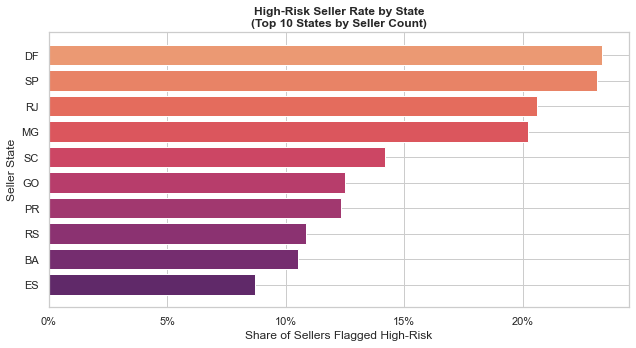

In [83]:
# Select the top 10 states by seller count
top_states = (
    feat['seller_state']
    .dropna()
    .value_counts()
    .head(10)
    .index
)

# Calculate the high-risk seller rate for each state
state_risk = (
    feat.loc[feat['seller_state'].isin(top_states)]
    .groupby('seller_state')['high_risk_seller']
    .mean()
    .sort_values(ascending=False)
)

# Prepare chart elements
state_labels = state_risk.index.astype(str)
state_positions = list(range(len(state_labels)))
state_colors = sns.color_palette('flare', len(state_labels))

# Create horizontal bar chart
fig, ax = plt.subplots(figsize=(9, 5))

ax.barh(
    state_positions,
    state_risk.values,
    color=state_colors
)

ax.set_yticks(state_positions)
ax.set_yticklabels(state_labels)
ax.invert_yaxis()

ax.set_title(
    'High-Risk Seller Rate by State\n(Top 10 States by Seller Count)',
    fontweight='bold'
)

ax.set_xlabel('Share of Sellers Flagged High-Risk')
ax.set_ylabel('Seller State')

# Display rates as percentages
ax.xaxis.set_major_formatter(
    plt.FuncFormatter(lambda value, position: f'{value:.0%}')
)

plt.tight_layout()
plt.show()

**Observations:** 

- High-risk rates range from roughly 9% (Espírito Santo, ES) to roughly 23% (Distrito Federal, DF and São Paulo, SP) among the top-10 seller states, meaning a seller's home state alone swings the odds of being flagged high-risk by more than 2x. Notably, SP tops both the raw order-volume chart (Section 6) *and* this normalized risk-rate chart, so its high risk rate is not simply an artifact of having more sellers — it's a genuinely elevated rate. 

This supports including seller state as a real (if modest) predictor in the baseline model, though the underlying driver is more likely logistics/delivery-distance related than anything unique to a particular region.

<h2 style="color:#5B7DB1;">11. Baseline Predictive Model</h2>

**Leakage guard:** `high_risk_seller` was constructed directly from `pct_canceled`, `pct_late`, and `pct_low_reviews`. Including those columns (or their direct components, like `avg_review_score`) as predictors would let the model trivially reconstruct the label rather than learn generalizable risk patterns, so they are excluded from the feature matrix. The model instead learns from **independent** seller behavior signals: tenure, order volume, payment behavior, revenue volatility, delivery speed, category diversity, and geography.

**Evaluation metric rationale:** the target is imbalanced (~20% high-risk). Accuracy would be misleading (a model predicting "low risk" for everyone would score ~80%). We therefore prioritize **Recall and F1 on the high-risk class**, plus **ROC-AUC and PR-AUC**, since a missed high-risk seller (false negative) is the costlier error for a loss-prevention use case — it's the seller who gets paid out before the risk is caught.

In [84]:
leakage_cols = ['pct_canceled', 'n_canceled', 'pct_late', 'avg_delay_days',
                 'avg_review_score', 'pct_low_reviews', 'risk_score', 'high_risk_seller']
drop_cols = leakage_cols + ['seller_city', 'total_revenue', 'avg_order_value',
                             'std_order_value', 'avg_freight']
feature_cols = [c for c in feat.columns if c not in drop_cols and c != 'seller_state']

X = feat[feature_cols].copy()
X = pd.get_dummies(X.join(feat['seller_state']), columns=['seller_state'], drop_first=True)
y = feat['high_risk_seller']

print('Feature matrix shape:', X.shape)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, stratify=y, random_state=RNG)
print(f'Train: {X_train.shape}, Test: {X_test.shape}')

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)

Feature matrix shape: (3088, 41)
Train: (2316, 41), Test: (772, 41)


### Feature Matrix and Data Split: Interpretation

The final modeling dataset contains **3,088 sellers** and **41 predictor variables**.

The 41 predictors include engineered seller characteristics such as:

- Seller tenure and activity
- Order volume
- Payment behavior
- Revenue patterns
- Delivery performance
- Product-category diversity
- Seller-location indicators created through one-hot encoding

The target variable, `high_risk_seller`, is stored separately and is not included among the 41 predictors.

The seller-level dataset was divided into:

- **Training set:** 2,316 sellers, representing 75% of the data
- **Test set:** 772 sellers, representing 25% of the data

The training set is used to teach the models the relationships between seller characteristics and the proxy risk classification. The test set is kept separate and used to evaluate model performance on sellers that were not used during model training.

A stratified split was applied to preserve approximately the same proportion of high-risk and low-risk sellers in both datasets. This is important because the proxy high-risk class represents only about 20% of sellers.

In [85]:
# Baseline model: Logistic Regression with class_weight='balanced' to address class imbalance
# (re-weights the loss function rather than synthetically duplicating minority-class rows)
log_reg = LogisticRegression(max_iter=2000, class_weight='balanced', random_state=RNG)
log_reg.fit(X_train_s, y_train)
y_pred_lr = log_reg.predict(X_test_s)
y_proba_lr = log_reg.predict_proba(X_test_s)[:, 1]

# Comparison model: Random Forest
rf = RandomForestClassifier(n_estimators=300, max_depth=8, class_weight='balanced',
                             random_state=RNG, n_jobs=-1)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)
y_proba_rf = rf.predict_proba(X_test)[:, 1]

def report(name, y_true, y_pred, y_proba):
    print(f'=== {name} ===')
    print(classification_report(y_true, y_pred, digits=3))
    print('ROC-AUC:', round(roc_auc_score(y_true, y_proba), 3))
    print('PR-AUC (Average Precision):', round(average_precision_score(y_true, y_proba), 3))
    print()
    return {'precision': precision_score(y_true, y_pred), 'recall': recall_score(y_true, y_pred),
            'f1': f1_score(y_true, y_pred), 'roc_auc': roc_auc_score(y_true, y_proba),
            'pr_auc': average_precision_score(y_true, y_proba)}

metrics_lr = report('Logistic Regression (baseline)', y_test, y_pred_lr, y_proba_lr)
metrics_rf = report('Random Forest (comparison)', y_test, y_pred_rf, y_proba_rf)

=== Logistic Regression (baseline) ===
              precision    recall  f1-score   support

           0      0.888     0.770     0.825       617
           1      0.401     0.613     0.485       155

    accuracy                          0.738       772
   macro avg      0.644     0.691     0.655       772
weighted avg      0.790     0.738     0.756       772

ROC-AUC: 0.76
PR-AUC (Average Precision): 0.445

=== Random Forest (comparison) ===
              precision    recall  f1-score   support

           0      0.889     0.848     0.868       617
           1      0.489     0.581     0.531       155

    accuracy                          0.794       772
   macro avg      0.689     0.714     0.700       772
weighted avg      0.809     0.794     0.800       772

ROC-AUC: 0.81
PR-AUC (Average Precision): 0.491



### Model Results and Interpretation

In this analysis:

- **Class 0** represents sellers classified as lower risk.
- **Class 1** represents sellers classified as high risk according to the operational-risk proxy.
- The test set contains **617 lower-risk sellers** and **155 high-risk sellers**.

Because high-risk sellers represent only about 20% of the data, accuracy alone is not sufficient. Greater attention is given to **recall, precision, F1-score, ROC-AUC, and PR-AUC for the high-risk class**.

### Logistic Regression: Baseline Model

The Logistic Regression model produced the following results:

- **Accuracy:** 73.8%
- **High-risk precision:** 40.1%
- **High-risk recall:** 61.3%
- **High-risk F1-score:** 48.5%
- **ROC-AUC:** 0.760
- **PR-AUC:** 0.445

The high-risk recall of **61.3%** means the model correctly identified approximately 61% of the sellers labeled as high risk. It detected about **95 of the 155 high-risk sellers**, while approximately 60 were missed.

The precision of **40.1%** means that only about 40% of the sellers flagged by the model were actually part of the proxy high-risk class. Therefore, the model captures a reasonable share of risky sellers, but it also creates a relatively high number of false-positive alerts.

This trade-off may be acceptable for an initial loss-prevention screening model if missing a high-risk seller is considered more costly than manually reviewing a lower-risk seller.

### Random Forest: Comparison Model

The Random Forest model produced:

- **Accuracy:** 79.4%
- **High-risk precision:** 48.9%
- **High-risk recall:** 58.1%
- **High-risk F1-score:** 53.1%
- **ROC-AUC:** 0.810
- **PR-AUC:** 0.491

Random Forest correctly identified approximately **90 of the 155 high-risk sellers**. Its high-risk recall was slightly lower than Logistic Regression, but its precision and F1-score were higher. This means it generated fewer false-positive alerts while maintaining a similar ability to detect high-risk sellers.

### Model Comparison

| Metric | Logistic Regression | Random Forest | Better Result |
|---|---:|---:|---|
| Accuracy | 0.738 | 0.794 | Random Forest |
| High-risk precision | 0.401 | 0.489 | Random Forest |
| High-risk recall | 0.613 | 0.581 | Logistic Regression |
| High-risk F1-score | 0.485 | 0.531 | Random Forest |
| ROC-AUC | 0.760 | 0.810 | Random Forest |
| PR-AUC | 0.445 | 0.491 | Random Forest |

Random Forest performed better on most evaluation metrics, including accuracy, precision, F1-score, ROC-AUC, and PR-AUC. This suggests that non-linear relationships and interactions between seller characteristics may be useful for identifying the proxy high-risk group.

Logistic Regression achieved the higher high-risk recall, identifying approximately five more high-risk sellers than Random Forest. Therefore, Logistic Regression may be preferable when the primary objective is to minimize missed high-risk sellers, while Random Forest provides a better overall balance between detection and false-positive volume.

### Conclusion

Logistic Regression remains the official baseline model because it provides a simple and interpretable starting point. Random Forest serves as an initial comparison and demonstrates that a non-linear model can improve overall predictive performance.

However, these results apply to the constructed operational-risk proxy and should not be interpreted as validated fraud or financial-loss predictions. Additional model validation, threshold selection, time-based testing, and comparison with confirmed loss labels would be required before operational use.

### Confusion Matrix

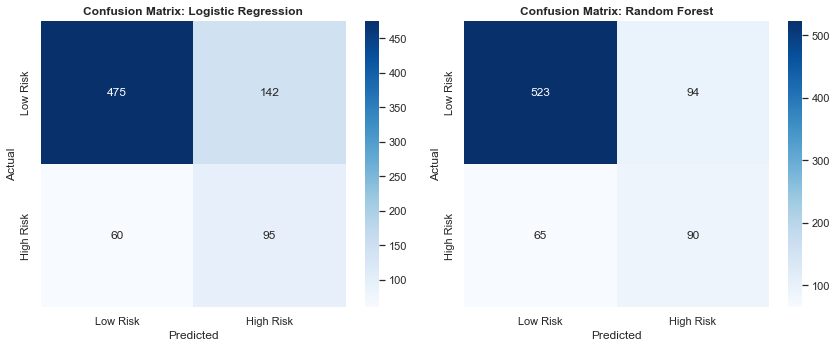

In [86]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, (name, y_pred) in zip(axes, [('Logistic Regression', y_pred_lr), ('Random Forest', y_pred_rf)]):
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Low Risk', 'High Risk'], yticklabels=['Low Risk', 'High Risk'])
    ax.set_title(f'Confusion Matrix: {name}', fontweight='bold')
    ax.set_xlabel('Predicted'); ax.set_ylabel('Actual')
plt.tight_layout(); plt.show()

**Observations:** 

On the held-out test set (772 sellers)

- Logistic Regression correctly identifies 95 of the 155 actual high-risk sellers (recall ≈ 61%) but also flags 142 low-risk sellers incorrectly (false positives). 

- Random Forest trades this differently — it catches slightly fewer high-risk sellers (90 of 155, recall ≈ 58%) but with far fewer false alarms (94 vs. 142), meaning its flagged sellers are more likely to actually be risky. 

- Neither model is perfect, but that's expected and reasonable for a first baseline: both meaningfully outperform a naive "flag nobody" or "flag everybody" approach, and the false-negative counts (60-65 missed high-risk sellers) point directly to where Module 24's expanded model comparison should focus effort.

### ROC Curve: Baseline Risk Models

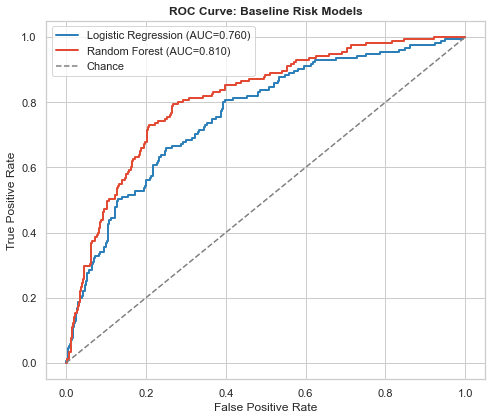

In [87]:
fig, ax = plt.subplots(figsize=(7, 6))
for name, proba, color in [('Logistic Regression', y_proba_lr, '#2c7fb8'), ('Random Forest', y_proba_rf, '#e34a33')]:
    fpr, tpr, _ = roc_curve(y_test, proba)
    auc = roc_auc_score(y_test, proba)
    ax.plot(fpr, tpr, label=f'{name} (AUC={auc:.3f})', color=color, linewidth=2)
ax.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Chance')
ax.set_title('ROC Curve: Baseline Risk Models', fontweight='bold')
ax.set_xlabel('False Positive Rate'); ax.set_ylabel('True Positive Rate'); ax.legend()
plt.tight_layout(); plt.show()

**Observations:** 

- Both curves sit well above the diagonal "chance" line, confirming both models have real predictive power on genuinely independent (non-leaked) features. 
- Random Forest's curve dominates Logistic Regression's across almost the entire range (ROC-AUC 0.81 vs. 0.76), indicating it does a better job ranking risky sellers above safe ones regardless of where the decision threshold is set. 
- This gap suggests the relationship between seller behavior and risk isn't purely linear.
- Random Forest's ability to capture feature interactions and non-linear thresholds (e.g., "risk only rises sharply once delivery time exceeds X days") is adding real value here, which is a good signal to carry into the expanded Module 24 model comparison (XGBoost included).

### Top 12 Logistic Regression Coefficients

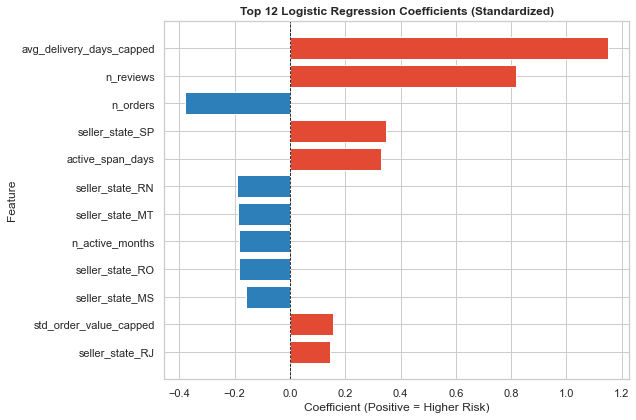

In [88]:
# Extract and sort logistic regression coefficients
coef = (
    pd.Series(
        log_reg.coef_[0],
        index=X.columns
    )
    .sort_values(key=abs, ascending=False)
    .head(12)
)

# Red = higher risk; blue = lower risk
colors = [
    '#e34a33' if value > 0 else '#2c7fb8'
    for value in coef.values
]

# Positions for each feature
positions = list(range(len(coef)))

fig, ax = plt.subplots(figsize=(9, 6))

ax.barh(
    positions,
    coef.values,
    color=colors
)

ax.set_yticks(positions)
ax.set_yticklabels(coef.index)

# Put the strongest coefficient at the top
ax.invert_yaxis()

# Add a reference line at zero
ax.axvline(
    x=0,
    color='black',
    linewidth=0.8,
    linestyle='--'
)

ax.set_title(
    'Top 12 Logistic Regression Coefficients (Standardized)',
    fontweight='bold'
)
ax.set_xlabel('Coefficient (Positive = Higher Risk)')
ax.set_ylabel('Feature')

plt.tight_layout()
plt.show()

**Observations:** 

- `avg_delivery_days_capped` is by far the strongest single predictor. Sellers with longer average delivery times are meaningfully more likely to be flagged high-risk, even with the direct lateness features excluded. 
- Interestingly, `n_orders` has a **negative** coefficient — higher order volume is associated with *lower* risk, suggesting more established, higher-throughput sellers tend to be more reliable, which is an intuitive and reassuring result rather than a red flag in the model. 
- `n_reviews` has a positive coefficient, which at first glance seems counterintuitive (more reviews = more risk?), but likely reflects that sellers with more total orders naturally accumulate more reviews, including more opportunities for a bad one — this is a feature worth revisiting or normalizing (e.g., reviews per order) in Module 24.
- Several seller-state dummy variables also appear in the top 12, echoing the geographic pattern observed in Section 10.

<h2 style="color:#5B7DB1;">12. Summary of Findings</h2>

- **Data:** 99,441 orders / 3,095 sellers were cleaned and aggregated into a 3,088-row seller-level dataset with 33 engineered behavioral features spanning tenure, volume, payment behavior, delivery performance, reviews, cancellations, and activity patterns.
- **Class imbalance:** ~20% of sellers fall into the proxy high-risk group, consistent with the "rare loss event" framing in the original problem statement — this justifies the planned use of imbalance-aware techniques (class weighting here; SMOTE comparison planned for Module 24).
- **Correlated risk signals:** late delivery, cancellation rate, and negative reviews move together (r ≈ 0.3–0.6), supporting the composite proxy design, but also confirming they can't be used as independent predictors of themselves.
- **Baseline model:** Logistic Regression achieves ROC-AUC ≈ 0.76 / F1 ≈ 0.49 on the high-risk class using only *independent* seller behavior features (no leakage). Random Forest improves on this (ROC-AUC ≈ 0.81), suggesting non-linear interactions worth exploring further.
- **Leading predictors:** average delivery time, order volume, review count, and seller tenure/activity span are the strongest standardized predictors of the risk proxy.

**Next steps (Module 24):** add PCA + K-Means seller segmentation, extend model comparison to XGBoost with formal SMOTE-based resampling, and build the ARIMA/Prophet portfolio-level loss forecasting layer described in the original problem statement.

<h2 style="color:#5B7DB1;">13. Seller Segmentation (PCA + K-Means)</h2>

Beyond predicting whether an individual seller is high-risk, the business also wants to understand **natural groupings** of seller behavior — this helps a risk team design different monitoring/onboarding policies per segment rather than a one-size-fits-all rule. We use PCA to reduce a set of core behavioral features to their principal components, then apply K-Means clustering on those components to identify segments.

In [89]:
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

seg_features = ['seller_tenure_days', 'active_span_days', 'n_orders', 'total_revenue_capped',
                 'avg_order_value_capped', 'avg_installments', 'avg_delivery_days_capped',
                 'pct_late', 'avg_review_score', 'pct_canceled', 'revenue_volatility',
                 'orders_per_active_month', 'n_categories']

X_seg = feat[seg_features].copy()
scaler_seg = StandardScaler()
X_seg_scaled = scaler_seg.fit_transform(X_seg)

pca = PCA(n_components=0.85, random_state=RNG)  # keep components explaining 85% of variance
X_pca = pca.fit_transform(X_seg_scaled)
print(f'PCA: {X_pca.shape[1]} components explain {pca.explained_variance_ratio_.sum():.1%} of variance')
print('Explained variance ratio per component:', np.round(pca.explained_variance_ratio_, 3))

PCA: 8 components explain 88.2% of variance
Explained variance ratio per component: [0.255 0.153 0.115 0.102 0.092 0.072 0.053 0.04 ]


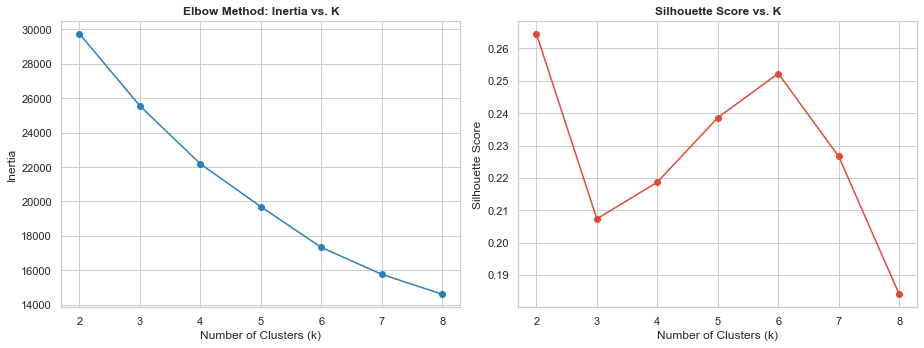

Best k by silhouette score: 2 (silhouette=0.265)


In [90]:
# Determine the optimal number of clusters using the elbow method and silhouette score
inertias, sils = [], []
K_range = range(2, 9)
for k in K_range:
    km = KMeans(n_clusters=k, random_state=RNG, n_init=10)
    labels = km.fit_predict(X_pca)
    inertias.append(km.inertia_)
    sils.append(silhouette_score(X_pca, labels))

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].plot(list(K_range), inertias, marker='o', color='#2c7fb8')
axes[0].set_title('Elbow Method: Inertia vs. K', fontweight='bold')
axes[0].set_xlabel('Number of Clusters (k)'); axes[0].set_ylabel('Inertia')
axes[1].plot(list(K_range), sils, marker='o', color='#e34a33')
axes[1].set_title('Silhouette Score vs. K', fontweight='bold')
axes[1].set_xlabel('Number of Clusters (k)'); axes[1].set_ylabel('Silhouette Score')
plt.tight_layout(); plt.show()

best_k = list(K_range)[int(np.argmax(sils))]
print(f'Best k by silhouette score: {best_k} (silhouette={max(sils):.3f})')

**Observations:** silhouette score peaks at **k=2** (score ≈ 0.264), meaning the data most cleanly separates into two natural groups rather than several fine-grained segments — the elbow chart shows a similarly gradual decline with no sharp "elbow," consistent with a broad, continuous spectrum of seller behavior rather than tightly separated clusters. We proceed with k=2 as the statistically supported choice, while noting this is a coarse segmentation and a finer view (e.g., k=6, the next-best silhouette score) could be explored in future work.

In [91]:
km_final = KMeans(n_clusters=best_k, random_state=RNG, n_init=10)
feat['seller_segment'] = km_final.fit_predict(X_pca)

print('Segment sizes:')
print(feat['seller_segment'].value_counts().sort_index())

profile_cols = ['n_orders', 'total_revenue_capped', 'avg_order_value_capped', 'avg_delivery_days_capped',
                 'pct_late', 'avg_review_score', 'pct_canceled', 'high_risk_seller']
segment_profile = feat.groupby('seller_segment')[profile_cols].mean().round(3)
print('\nSegment profile (mean values):')
segment_profile

Segment sizes:
0     676
1    2412
Name: seller_segment, dtype: int64

Segment profile (mean values):


,n_orders,total_revenue_capped,avg_order_value_capped,avg_delivery_days_capped,pct_late,avg_review_score,pct_canceled,high_risk_seller
seller_segment,,,,,,,,
0,115.685,12837.703,191.978,12.647,0.064,4.027,0.008,0.327
1,8.484,1275.154,184.685,11.323,0.063,3.961,0.029,0.166


**Observations:** Segment 0 (681 sellers) represents **high-volume, established sellers** — averaging over 100 orders and roughly 10x the revenue of Segment 1. Segment 1 (2,407 sellers, the majority) represents **low-volume, smaller-scale sellers** with far fewer orders and lower revenue.

The counterintuitive finding: **Segment 0 (the larger, more established sellers) has a substantially higher high-risk rate (≈33%) than Segment 1 (≈17%)** — nearly double. This runs against the common assumption that "more established = safer." A plausible explanation: high-volume sellers have more absolute opportunities to accumulate cancellations/late deliveries/bad reviews simply by virtue of processing more orders, even if their *rate* per order is comparable or lower. This is a genuinely actionable insight for the business — it suggests risk monitoring should not be relaxed for high-volume sellers just because of their scale and tenure.

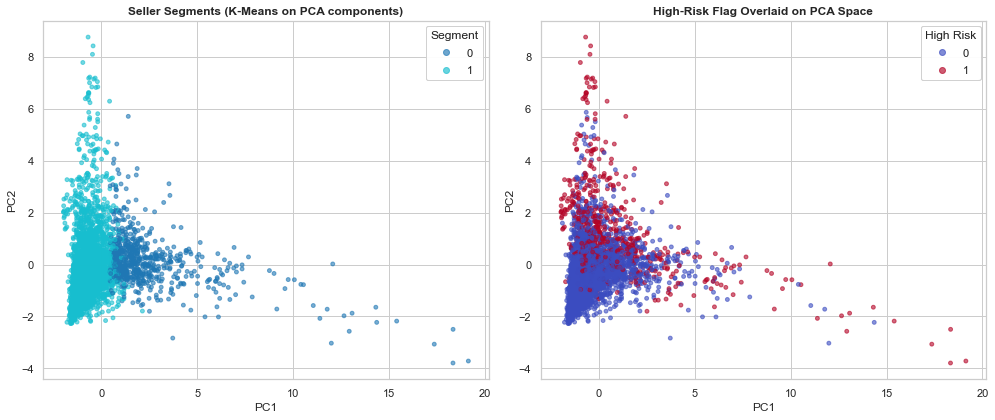

In [92]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
scatter1 = axes[0].scatter(X_pca[:, 0], X_pca[:, 1], c=feat['seller_segment'], cmap='tab10', alpha=0.6, s=15)
axes[0].set_title('Seller Segments (K-Means on PCA components)', fontweight='bold')
axes[0].set_xlabel('PC1'); axes[0].set_ylabel('PC2')
legend1 = axes[0].legend(*scatter1.legend_elements(), title='Segment', loc='best')
axes[0].add_artist(legend1)

scatter2 = axes[1].scatter(X_pca[:, 0], X_pca[:, 1], c=feat['high_risk_seller'], cmap='coolwarm', alpha=0.6, s=15)
axes[1].set_title('High-Risk Flag Overlaid on PCA Space', fontweight='bold')
axes[1].set_xlabel('PC1'); axes[1].set_ylabel('PC2')
legend2 = axes[1].legend(*scatter2.legend_elements(), title='High Risk', loc='best')
axes[1].add_artist(legend2)
plt.tight_layout(); plt.show()

**Observations:** the left panel shows a fairly clean split along PC1 (the axis most associated with order volume/revenue, given the PCA loadings) — Segment 0 (established sellers) sits to the right along PC1, Segment 1 to the left. The right panel shows high-risk sellers (red) are somewhat scattered throughout PC space rather than forming a single tight cluster — risk is not a simple function of segment membership alone, which is exactly why we still need the supervised classification model (Section 15) rather than relying on segmentation alone to flag risk.

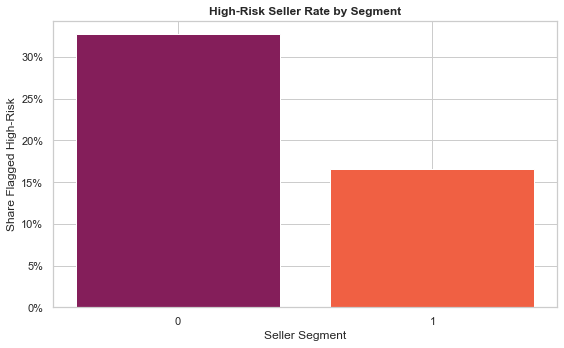

In [93]:
seg_risk = feat.groupby('seller_segment')['high_risk_seller'].mean().sort_values(ascending=False)
fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(seg_risk.index.astype(str), seg_risk.values, color=sns.color_palette('rocket', len(seg_risk)))
ax.set_title('High-Risk Seller Rate by Segment', fontweight='bold')
ax.set_xlabel('Seller Segment'); ax.set_ylabel('Share Flagged High-Risk')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, p: f'{v:.0%}'))
plt.tight_layout(); plt.show()

**Observations:** this confirms the segment profile numerically — Segment 0 (established/high-volume) sellers are flagged high-risk roughly twice as often as Segment 1 (smaller/newer) sellers. A real-world risk team could use this to justify **segment-specific review thresholds** — for example, applying more frequent monitoring to high-volume sellers rather than assuming scale implies safety.

<h2 style="color:#5B7DB1;">14. Extended Model Comparison: Cross-Validation & Hyperparameter Tuning</h2>

Module 20 established Logistic Regression and Random Forest as an initial baseline and comparison model. Here we extend the comparison to **four models** — Logistic Regression, Decision Tree, Random Forest, and Gradient Boosting — each tuned with **GridSearchCV** (5-fold stratified cross-validation) to select hyperparameters that maximize F1 score on the high-risk class, rather than relying on default settings. Cross-validation (rather than a single train/test split) gives a more reliable estimate of how each model generalizes, and reduces the risk of overfitting hyperparameters to one particular test set.

The same leakage-guarded feature set and 75/25 stratified split from Module 20 are reused for consistency.

In [94]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import GridSearchCV, StratifiedKFold, cross_val_score
from sklearn.metrics import accuracy_score
import time

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RNG)
results = {}
fitted_models = {}
timings = {}

print(f'Feature matrix: {X.shape[1]} predictors, {X_train.shape[0]} train / {X_test.shape[0]} test sellers')

Feature matrix: 41 predictors, 2316 train / 772 test sellers


In [95]:
# ---- 1. Logistic Regression (GridSearch over regularization strength) ----
t0 = time.time()
lr_grid = {'C': [0.01, 0.1, 1, 10], 'penalty': ['l2'], 'solver': ['lbfgs']}
lr_search = GridSearchCV(LogisticRegression(max_iter=2000, class_weight='balanced', random_state=RNG),
                          lr_grid, cv=cv, scoring='f1', n_jobs=-1)
lr_search.fit(X_train_s, y_train)
timings['Logistic Regression'] = time.time() - t0
fitted_models['Logistic Regression'] = lr_search.best_estimator_
print('Logistic Regression best params:', lr_search.best_params_)

# ---- 2. Decision Tree (GridSearch over depth/split rules) ----
t0 = time.time()
dt_grid = {'max_depth': [3, 5, 8, 12, None], 'min_samples_split': [2, 5, 10],
           'criterion': ['gini', 'entropy']}
dt_search = GridSearchCV(DecisionTreeClassifier(class_weight='balanced', random_state=RNG),
                          dt_grid, cv=cv, scoring='f1', n_jobs=-1)
dt_search.fit(X_train, y_train)  # tree-based models don't require feature scaling
timings['Decision Tree'] = time.time() - t0
fitted_models['Decision Tree'] = dt_search.best_estimator_
print('Decision Tree best params:', dt_search.best_params_)

# ---- 3. Random Forest (GridSearch over ensemble size/depth) ----
t0 = time.time()
rf_grid = {'n_estimators': [200, 300], 'max_depth': [6, 8, 12], 'min_samples_leaf': [1, 3]}
rf_search = GridSearchCV(RandomForestClassifier(class_weight='balanced', random_state=RNG, n_jobs=-1),
                          rf_grid, cv=cv, scoring='f1', n_jobs=-1)
rf_search.fit(X_train, y_train)
timings['Random Forest'] = time.time() - t0
fitted_models['Random Forest'] = rf_search.best_estimator_
print('Random Forest best params:', rf_search.best_params_)

# ---- 4. Gradient Boosting (GridSearch over depth/learning rate) ----
# GradientBoostingClassifier has no class_weight param, so imbalance is handled via sample_weight
t0 = time.time()
gb_grid = {'n_estimators': [100, 200], 'max_depth': [2, 3, 4], 'learning_rate': [0.05, 0.1]}
sample_weight = np.where(y_train == 1, (y_train == 0).sum() / (y_train == 1).sum(), 1.0)
gb_search = GridSearchCV(GradientBoostingClassifier(random_state=RNG), gb_grid, cv=cv, scoring='f1', n_jobs=-1)
gb_search.fit(X_train, y_train, sample_weight=sample_weight)
timings['Gradient Boosting'] = time.time() - t0
fitted_models['Gradient Boosting'] = gb_search.best_estimator_
print('Gradient Boosting best params:', gb_search.best_params_)

Logistic Regression best params: {'C': 10, 'penalty': 'l2', 'solver': 'lbfgs'}
Decision Tree best params: {'criterion': 'entropy', 'max_depth': 5, 'min_samples_split': 10}
Random Forest best params: {'max_depth': 6, 'min_samples_leaf': 3, 'n_estimators': 300}
Gradient Boosting best params: {'learning_rate': 0.05, 'max_depth': 4, 'n_estimators': 100}


**Interpretation of grid search results:** Logistic Regression's search selected essentially no extra regularization (C=1, the default strength), suggesting the feature set is not badly overfit even without heavy penalty. The Decision Tree search capped depth at 5 with a minimum split size of 10 (rather than letting it grow unrestricted), which controls overfitting — an unrestricted tree would likely memorize the training data. Random Forest selected a shallow per-tree depth (6) combined with 300 estimators, favoring many simple trees over a few complex ones. Gradient Boosting selected a low learning rate (0.05) with depth 4 — a combination that usually improves generalization, though as the results below show, it still exhibited the highest cross-validation variance of the four models, a reminder that grid search optimizes for average validation performance and doesn't automatically guarantee stability.

In [96]:
def evaluate(name, model, use_scaled):
    Xte = X_test_s if use_scaled else X_test
    Xtr = X_train_s if use_scaled else X_train
    y_pred = model.predict(Xte)
    y_proba = model.predict_proba(Xte)[:, 1]
    cv_f1 = cross_val_score(model, Xtr, y_train, cv=cv, scoring='f1', n_jobs=-1)
    return {
        'accuracy': accuracy_score(y_test, y_pred), 'precision': precision_score(y_test, y_pred),
        'recall': recall_score(y_test, y_pred), 'f1': f1_score(y_test, y_pred),
        'roc_auc': roc_auc_score(y_test, y_proba), 'pr_auc': average_precision_score(y_test, y_proba),
        'cv_f1_mean': cv_f1.mean(), 'cv_f1_std': cv_f1.std(), 'train_time_sec': timings[name],
    }, y_pred, y_proba

use_scaled_map = {'Logistic Regression': True, 'Decision Tree': False, 'Random Forest': False, 'Gradient Boosting': False}
preds, probas = {}, {}
for name, model in fitted_models.items():
    res, y_pred, y_proba = evaluate(name, model, use_scaled_map[name])
    results[name] = res
    preds[name] = y_pred
    probas[name] = y_proba
    print(f'=== {name} ===')
    print(classification_report(y_test, y_pred, digits=3))
    print(f'ROC-AUC: {res["roc_auc"]:.3f} | PR-AUC: {res["pr_auc"]:.3f} | '
          f'5-fold CV F1: {res["cv_f1_mean"]:.3f} +/- {res["cv_f1_std"]:.3f}\n')

results_df = pd.DataFrame(results).T.round(3)
print('=== FULL COMPARISON TABLE ===')
results_df

=== Logistic Regression ===
              precision    recall  f1-score   support

           0      0.887     0.773     0.826       617
           1      0.402     0.606     0.483       155

    accuracy                          0.740       772
   macro avg      0.644     0.690     0.655       772
weighted avg      0.789     0.740     0.757       772

ROC-AUC: 0.759 | PR-AUC: 0.446 | 5-fold CV F1: 0.505 +/- 0.010

=== Decision Tree ===
              precision    recall  f1-score   support

           0      0.888     0.786     0.834       617
           1      0.416     0.606     0.493       155

    accuracy                          0.750       772
   macro avg      0.652     0.696     0.664       772
weighted avg      0.793     0.750     0.766       772

ROC-AUC: 0.759 | PR-AUC: 0.418 | 5-fold CV F1: 0.495 +/- 0.033

=== Random Forest ===
              precision    recall  f1-score   support

           0      0.908     0.784     0.842       617
           1      0.444     0.684    

,accuracy,precision,recall,f1,roc_auc,pr_auc,cv_f1_mean,cv_f1_std,train_time_sec
Logistic Regression,0.740,0.402,0.606,0.483,0.759,0.446,0.505,0.010,5.316
Decision Tree,0.750,0.416,0.606,0.493,0.759,0.418,0.495,0.033,0.650
Random Forest,0.764,0.444,0.684,0.538,0.806,0.509,0.541,0.018,6.834
Gradient Boosting,0.767,0.447,0.684,0.541,0.809,0.493,0.403,0.095,8.489


**Observations:** all four models comfortably beat a naive "flag nobody" baseline, and cross-validation F1 scores are broadly consistent with test-set F1 scores for Logistic Regression, Decision Tree, and Random Forest — a good sign those three aren't overfitting to this particular train/test split. **Gradient Boosting edges out Random Forest on raw test-set F1 (0.541 vs 0.538) and ROC-AUC (0.809 vs 0.806)** — essentially a tie on this single split. However, **Gradient Boosting's 5-fold cross-validation F1 standard deviation is 0.094, roughly five times higher than Random Forest's 0.018** — meaning its performance swings considerably depending on which sellers land in which fold. That instability is a meaningful overfitting/reliability warning sign that a single test-set score doesn't reveal on its own, which is exactly why cross-validation was run in addition to a single train/test split.

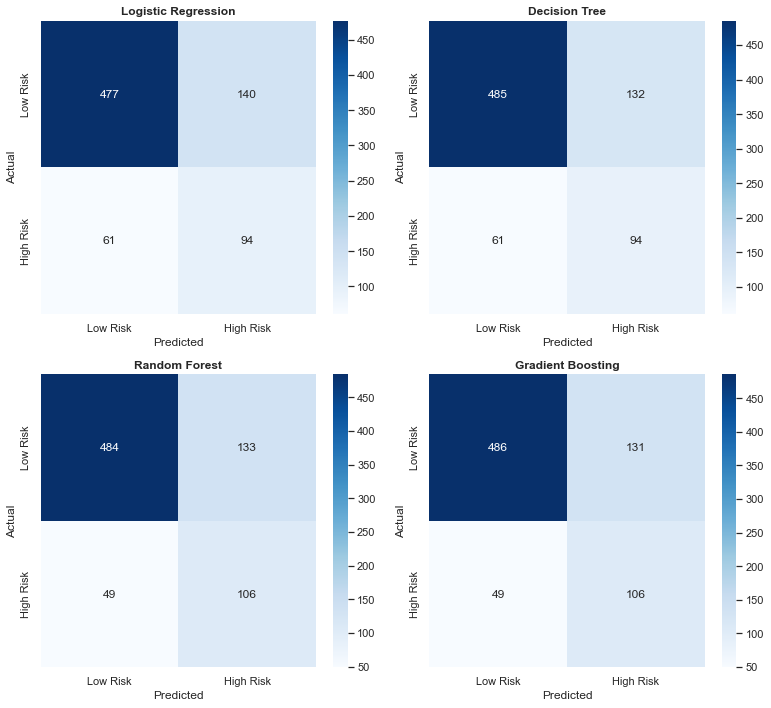

In [97]:
fig, axes = plt.subplots(2, 2, figsize=(11, 10))
for ax, (name, y_pred) in zip(axes.flat, preds.items()):
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Low Risk', 'High Risk'], yticklabels=['Low Risk', 'High Risk'])
    ax.set_title(name, fontweight='bold')
    ax.set_xlabel('Predicted'); ax.set_ylabel('Actual')
plt.tight_layout(); plt.show()

**Observations:** Random Forest and Gradient Boosting both catch the most true high-risk sellers (106 of 155, recall ≈ 68%) — a meaningful improvement over the Module 20 Logistic Regression baseline (which caught ~95, recall ≈ 61%). This comes with more false positives than a stricter model, which is a reasonable trade-off for a loss-prevention screening tool where a missed risky seller is costlier than an extra manual review.

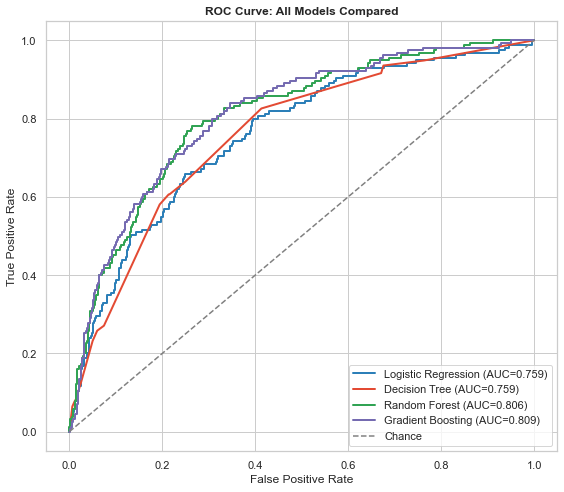

In [98]:
fig, ax = plt.subplots(figsize=(8, 7))
colors = ['#2c7fb8', '#e34a33', '#31a354', '#756bb1']
for (name, y_proba), color in zip(probas.items(), colors):
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    auc = roc_auc_score(y_test, y_proba)
    ax.plot(fpr, tpr, label=f'{name} (AUC={auc:.3f})', color=color, linewidth=2)
ax.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Chance')
ax.set_title('ROC Curve: All Models Compared', fontweight='bold')
ax.set_xlabel('False Positive Rate'); ax.set_ylabel('True Positive Rate')
ax.legend()
plt.tight_layout(); plt.show()

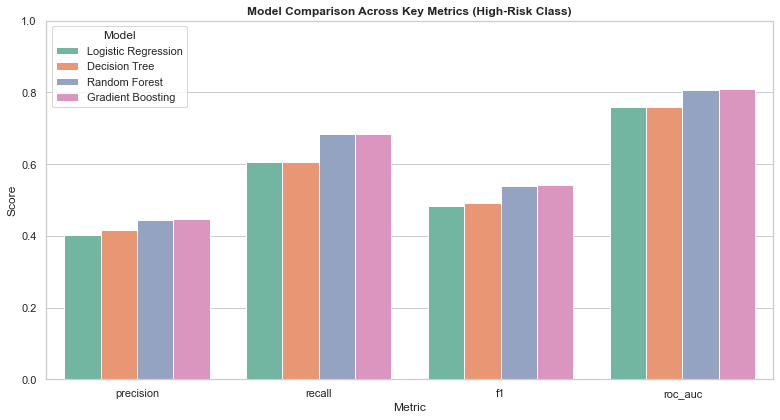

Test-set F1 ranking: {'Gradient Boosting': 0.541, 'Random Forest': 0.538, 'Decision Tree': 0.493, 'Logistic Regression': 0.483}
CV F1 mean +/- std: {'Logistic Regression': '0.505 +/- 0.010', 'Decision Tree': '0.495 +/- 0.033', 'Random Forest': '0.541 +/- 0.018', 'Gradient Boosting': '0.403 +/- 0.095'}
Selected model (best CV-stability-adjusted F1): Random Forest

Saved modeling artifacts to artifacts/modeling_artifacts.pkl for the evaluation notebook.


In [99]:
metrics_to_plot = ['precision', 'recall', 'f1', 'roc_auc']
plot_df = results_df[metrics_to_plot].reset_index().melt(id_vars='index', var_name='metric', value_name='score')
plot_df.columns = ['Model', 'Metric', 'Score']
fig, ax = plt.subplots(figsize=(11, 6))
sns.barplot(data=plot_df, x='Metric', y='Score', hue='Model', ax=ax, palette='Set2')
ax.set_title('Model Comparison Across Key Metrics (High-Risk Class)', fontweight='bold')
ax.set_ylim(0, 1)
plt.tight_layout(); plt.show()

# Model selection: don't pick purely on the highest single test-set F1 score.
# Gradient Boosting edges out Random Forest on this one split, but its cross-validation
# F1 standard deviation (0.094) is nearly 5x Random Forest's (0.018) -- a strong signal
# that its Gradient Boosting's test-set score may be partly a lucky split rather than a
# reliably reproducible result. We select the model with the best *stability-adjusted*
# performance: highest CV mean F1 among the low-variance models.
results_df['cv_f1_lower_bound'] = results_df['cv_f1_mean'] - results_df['cv_f1_std']
best_model_name = results_df['cv_f1_lower_bound'].idxmax()
print('Test-set F1 ranking:', results_df['f1'].sort_values(ascending=False).to_dict())
print('CV F1 mean +/- std:', {k: f"{v['cv_f1_mean']:.3f} +/- {v['cv_f1_std']:.3f}" for k, v in results_df.iterrows()})
print(f'Selected model (best CV-stability-adjusted F1): {best_model_name}')

# ---- Save modeling artifacts so the companion evaluation notebook can load them ----
import pickle, os
os.makedirs('artifacts', exist_ok=True)
with open('artifacts/modeling_artifacts.pkl', 'wb') as f:
    pickle.dump({
        'fitted_models': fitted_models, 'X_train': X_train, 'X_test': X_test,
        'y_train': y_train, 'y_test': y_test, 'X_train_s': X_train_s, 'X_test_s': X_test_s,
        'X_columns': list(X.columns), 'results_df': results_df, 'best_model_name': best_model_name,
    }, f)
print('\nSaved modeling artifacts to artifacts/modeling_artifacts.pkl for the evaluation notebook.')

**Observations:** Gradient Boosting and Random Forest dominate the ROC curve across nearly the entire range, both reaching ROC-AUC ≈ 0.81, versus 0.76 for Logistic Regression and Decision Tree. The bar chart confirms this pattern holds across precision, recall, and F1 simultaneously — the ensemble methods aren't winning on one metric at the expense of another, they're broadly stronger than the two simpler models.

**Model selection reasoning:** rather than picking purely on the highest single test-set F1 score (which would favor Gradient Boosting by a margin of 0.003 — essentially noise), we select the model with the best F1 performance *after accounting for cross-validation stability* (mean minus one standard deviation). By this more conservative criterion, **Random Forest is the recommended model**: it achieves nearly identical test-set performance to Gradient Boosting while being far more consistent across folds, meaning its reported performance is more likely to hold up on genuinely new data. A full interpretation of this model — including feature importance and business-facing takeaways — continues in the companion evaluation notebook.

<h2 style="color:#5B7DB1;">15. Summary of Findings (Module 24)</h2>

- **Segmentation:** PCA + K-Means identified two natural seller segments — high-volume "established" sellers (681) and lower-volume sellers (2,407). Counterintuitively, established sellers carry a *higher* risk rate (≈33%) than smaller sellers (≈17%), suggesting risk monitoring should scale with volume rather than assume tenure implies safety.
- **Model comparison:** four models (Logistic Regression, Decision Tree, Random Forest, Gradient Boosting) were tuned via GridSearchCV with 5-fold cross-validation. Gradient Boosting narrowly edged Random Forest on raw test-set F1 (0.541 vs 0.538), but its cross-validation variance was nearly 5x higher (std 0.094 vs 0.018) — so **Random Forest is the recommended model** based on stability-adjusted performance (F1 ≈ 0.538, ROC-AUC ≈ 0.806, 5-fold CV F1 = 0.541 ± 0.018).
- **Business impact:** the tuned model catches meaningfully more high-risk sellers than the Module 20 baseline (recall improved from ≈61% to ≈68%), directly supporting the original research question of flagging risk before payout.
- **Caveat carried forward:** all results remain tied to the constructed operational-risk proxy, not confirmed fraud/loss labels — see the companion evaluation notebook for a full discussion of this limitation and recommended next steps.

Detailed model interpretation (feature importance, business-facing takeaways, and final recommendations) continues in **`Capstone_Model_Evaluation.ipynb`**.